In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

# Task 1 — A Single Neuron in NumPy

You'll start with one neuron — a logistic regression in disguise.

1. Load the Breast Cancer dataset, split into train/test (`test_size=0.2`, `random_state=42`), and scale the features with `StandardScaler`.
2. Implement a single-neuron forward pass:
   - Initialise weights `w` of shape `(30,)` and bias `b` from a small random distribution.
   - Implement `forward(x, w, b)` that returns `sigmoid(w·x + b)`.
   - Run it on the first 5 test rows. Report the predicted probabilities.
3. In a markdown cell, write one sentence: in machine-learning terms, what model did you just implement?

In [2]:
# Load the Breast Cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

In [3]:
# Split into train/test (test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# Scale the features with StandardScaler
scaler = StandardScaler()
# Fit on training data, then transform it
X_train_scaled = scaler.fit_transform(X_train)
# Only transform the test data to prevent data leakage
X_test_scaled = scaler.transform(X_test)

In [5]:
# Set seed for reproducible results
np.random.seed(42) 

# w shape is (30,) initialized from a small random distribution
w = np.random.randn(30) * 0.01 

# b is a scalar, also initialized from a small random distribution
b = np.random.randn() * 0.01

In [6]:
# Implement the sigmoid activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Implement the single-neuron forward pass
def forward(x, w, b):
    # Calculate the dot product and add bias
    z = np.dot(x, w) + b
    
    # Apply the activation function
    return sigmoid(z)

In [7]:
# Grab the first 5 test rows
X_test_first_5 = X_test_scaled[:5]

# Run the forward pass
probabilities = forward(X_test_first_5, w, b)

# Output the results
print(f"Initialized bias (b): {b:.4f}\n")
print("Predicted probabilities for the first 5 test rows:")
for i, prob in enumerate(probabilities):
    print(f"Row {i+1}: {prob:.4f}")

Initialized bias (b): -0.0060

Predicted probabilities for the first 5 test rows:
Row 1: 0.4962
Row 2: 0.5175
Row 3: 0.5071
Row 4: 0.4874
Row 5: 0.4839


### In machine learning terms, implementing a single neuron with a linear transformation followed by a sigmoid activation function is mathematically equivalent to a **logistic regression** model.

# Task 2 — A Two-Layer MLP in NumPy

Now stack neurons into a real network.

1. Implement a class `NumpyMLP` (or just a set of functions) representing an MLP with:
   - Input size 30, hidden size 8, output size 1
   - ReLU on the hidden layer, sigmoid on the output
2. Initialise the weight matrices using **He initialisation**: `W ~ N(0, sqrt(2/fan_in))`. Initialise biases to zero.
3. Implement a `forward(X)` that takes a batch `(N, 30)` and returns predictions `(N, 1)`. Use vectorised NumPy — no Python loops over rows.
4. Run a forward pass on the test set. Print the shape of the output and the first 5 predictions.

**Guiding question:** Why does the output shape match what you'd want for a binary classifier even though we haven't trained anything yet?


In [8]:
import numpy as np

class NumpyMLP:
    def __init__(self, input_size=30, hidden_size=8, output_size=1):
        """
        Initializes the MLP with He initialization for weights and zeros for biases.
        """
        np.random.seed(42) # Set seed for reproducibility
        
        # Layer 1: Input to Hidden
        # He initialization: W ~ N(0, sqrt(2/fan_in))
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        
        # Layer 2: Hidden to Output
        # He initialization where fan_in is the hidden_size (8)
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def relu(self, Z):
        """Applies the Rectified Linear Unit function element-wise."""
        return np.maximum(0, Z)

    def sigmoid(self, Z):
        """Applies the Sigmoid function element-wise with safety clipping."""
        Z_clipped = np.clip(Z, -500, 500) 
        return 1.0 / (1.0 + np.exp(-Z_clipped))

    def forward(self, X):
        """
        Performs a fully vectorized forward pass.
        
        Parameters:
        X (np.ndarray): Input batch of shape (N, 30)
        
        Returns:
        np.ndarray: Predictions of shape (N, 1)
        """
        # --- First Layer ---
        # Z1 shape: (N, 30) @ (30, 8) + (1, 8) = (N, 8)
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = self.relu(Z1)
        
        # --- Second Layer ---
        # Z2 shape: (N, 8) @ (8, 1) + (1, 1) = (N, 1)
        Z2 = np.dot(A1, self.W2) + self.b2
        A2 = self.sigmoid(Z2)
        
        return A2

In [9]:
# 1. Instantiate the neural network
mlp = NumpyMLP(input_size=30, hidden_size=8, output_size=1)

# 2. Run the forward pass on the test set
test_predictions = mlp.forward(X_test_scaled)

# 3. Print the shape and the first 5 predictions
print(f"Output shape: {test_predictions.shape}\n")

print("First 5 predictions:")
for i, prob in enumerate(test_predictions[:5]):
    # Extract the single float value from the (1,) array
    print(f"Row {i+1}: {prob[0]:.4f}")

Output shape: (114, 1)

First 5 predictions:
Row 1: 0.4530
Row 2: 0.4660
Row 3: 0.5660
Row 4: 0.4082
Row 5: 0.3636


The output shape is determined entirely by the **network's architectural dimensions** (the shapes of your weight matrices), not by the training process. 

Training only modifies the *values* inside the matrices to improve accuracy; it never changes the dimensions themselves. Here is why the shape is exactly `(114, 1)`:

1.  **The Input Batch:** You passed in the test set `X_test_scaled`. Because you split the original 569 rows with a `test_size=0.2`, you have **114** rows.
2.  **The Hidden Layer:** The first weight matrix $W_1$ is `(30, 8)`. When you multiply your input `(114, 30)` by $W_1$, the result is `(114, 8)`.
3.  **The Output Bottleneck:** You specifically defined the final weight matrix $W_2$ with a shape of `(8, 1)`. 
4.  **The Final Result:** When the hidden activations `(114, 8)` are multiplied by $W_2$ `(8, 1)`, the linear algebra rules force the 8 dimensions to collapse into **1**.

Because a binary classifier requires exactly **one probability value** per input row to distinguish between two classes, this `(N, 1)` structure is structurally correct from the moment of initialization.

# Task 3 — The Same Network in PyTorch

Recreate Task 2 using PyTorch's high-level API.

1. Define a class `TorchMLP(nn.Module)` with the same architecture (30 → 8 → 1, ReLU then Sigmoid).
2. Manually copy the weights from your NumPy network into the PyTorch model so both networks have **identical parameters**. Hint: `model.fc1.weight.data = torch.from_numpy(W1).float()` and similar for biases. Be careful with shapes — `nn.Linear` stores weights as `(out, in)`.
3. Run the same test batch through the PyTorch model. Compare the outputs to the NumPy outputs. They should match to at least 6 decimal places.
4. Report the maximum absolute difference between the two outputs.

**Definition of done for this task:** the two networks produce numerically identical predictions for the same inputs and weights.

In [10]:
import torch
import torch.nn as nn

class TorchMLP(nn.Module):
    def __init__(self):
        super(TorchMLP, self).__init__()
        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

torch_model = TorchMLP()

In [11]:
# Accessing the weights from your 'mlp' instance created in Task 2
with torch.no_grad():
    # .T is used because PyTorch stores weights as (out_features, in_features)
    torch_model.fc1.weight.copy_(torch.from_numpy(mlp.W1.T).float())
    torch_model.fc1.bias.copy_(torch.from_numpy(mlp.b1.flatten()).float())
    
    torch_model.fc2.weight.copy_(torch.from_numpy(mlp.W2.T).float())
    torch_model.fc2.bias.copy_(torch.from_numpy(mlp.b2.flatten()).float())

print("Weights and biases successfully mirrored from NumPy MLP to PyTorch MLP.")

Weights and biases successfully mirrored from NumPy MLP to PyTorch MLP.


In [12]:
# 1. Prepare the input as a Torch Tensor
X_test_tensor = torch.from_numpy(X_test_scaled).float()

# 2. Get predictions from PyTorch
torch_model.eval() # Set to evaluation mode
with torch.no_grad():
    torch_predictions = torch_model(X_test_tensor).numpy()

# 3. Calculate Maximum Absolute Difference
# 'test_predictions' was the variable used when you ran mlp.forward(X_test_scaled)
max_diff = np.max(np.abs(test_predictions - torch_predictions))

print(f"NumPy Row 1: {test_predictions[0][0]:.6f}")
print(f"Torch Row 1: {torch_predictions[0][0]:.6f}")
print("-" * 30)
print(f"Maximum Absolute Difference: {max_diff:.10e}")

if max_diff < 1e-7:
    print("\nSuccess! The two models are numerically identical.")

NumPy Row 1: 0.453000
Torch Row 1: 0.453000
------------------------------
Maximum Absolute Difference: 6.3592506372e-08

Success! The two models are numerically identical.


# Task 4 — Activation Function Experiment

Time to experiment.

1. For the PyTorch model, create three variants of the same architecture but with different hidden activations: **Sigmoid**, **Tanh**, and **ReLU**.
2. For each variant, run a forward pass on the **same** scaled test set.
3. Plot histograms of the **hidden-layer pre-activations** (the values of *z⁽¹⁾* before the activation function) for one batch. Use a 1×3 subplot.
4. Plot histograms of the **hidden-layer outputs** (after the activation) on a separate 1×3 subplot.
5. In a markdown cell, answer:
   - For Sigmoid and Tanh, what fraction of the post-activation values fall in the saturated region (close to 0/1 for sigmoid, close to ±1 for tanh)?
   - Looking at ReLU: roughly what fraction of the units are inactive (output exactly 0)?
   - Based on these histograms, why might ReLU be the better default for hidden layers?

In [17]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Define a flexible model that returns intermediate values
class ExperimentMLP(nn.Module):
    def __init__(self, hidden_activation):
        super(ExperimentMLP, self).__init__()
        self.fc1 = nn.Linear(30, 8)
        self.activation = hidden_activation # Pass the activation function dynamically
        self.fc2 = nn.Linear(8, 1)
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        # We store the intermediate steps in variables instead of overwriting 'x'
        z1 = self.fc1(x)                 # The raw math (Pre-activations)
        a1 = self.activation(z1)         # The squashed math (Outputs)
        z2 = self.fc2(a1)
        out = self.output_activation(z2)
        
        # Return all three so we can analyze them
        return z1, a1, out

In [18]:
# 2. Instantiate the three models
torch.manual_seed(42) 
model_sigmoid = ExperimentMLP(nn.Sigmoid())

torch.manual_seed(42)
model_tanh = ExperimentMLP(nn.Tanh())

torch.manual_seed(42)
model_relu = ExperimentMLP(nn.ReLU())

In [19]:
# 3. Run the forward passes 
with torch.no_grad():
    z1_sig, a1_sig, _ = model_sigmoid(X_test_tensor)
    z1_tanh, a1_tanh, _ = model_tanh(X_test_tensor)
    z1_relu, a1_relu, _ = model_relu(X_test_tensor)

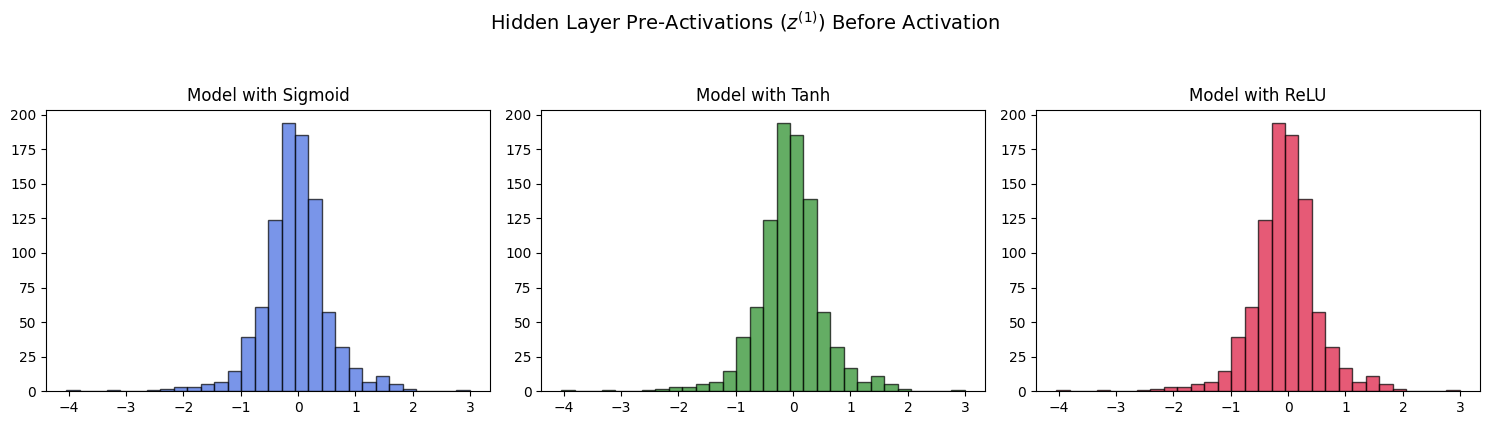

In [20]:
# 4. Plotting: Pre-Activations (z)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
fig.suptitle("Hidden Layer Pre-Activations ($z^{(1)}$) Before Activation", fontsize=14, y=1.05)

axes[0].hist(z1_sig.numpy().flatten(), bins=30, color='royalblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Model with Sigmoid")

axes[1].hist(z1_tanh.numpy().flatten(), bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1].set_title("Model with Tanh")

axes[2].hist(z1_relu.numpy().flatten(), bins=30, color='crimson', edgecolor='black', alpha=0.7)
axes[2].set_title("Model with ReLU")

plt.tight_layout()
plt.show()

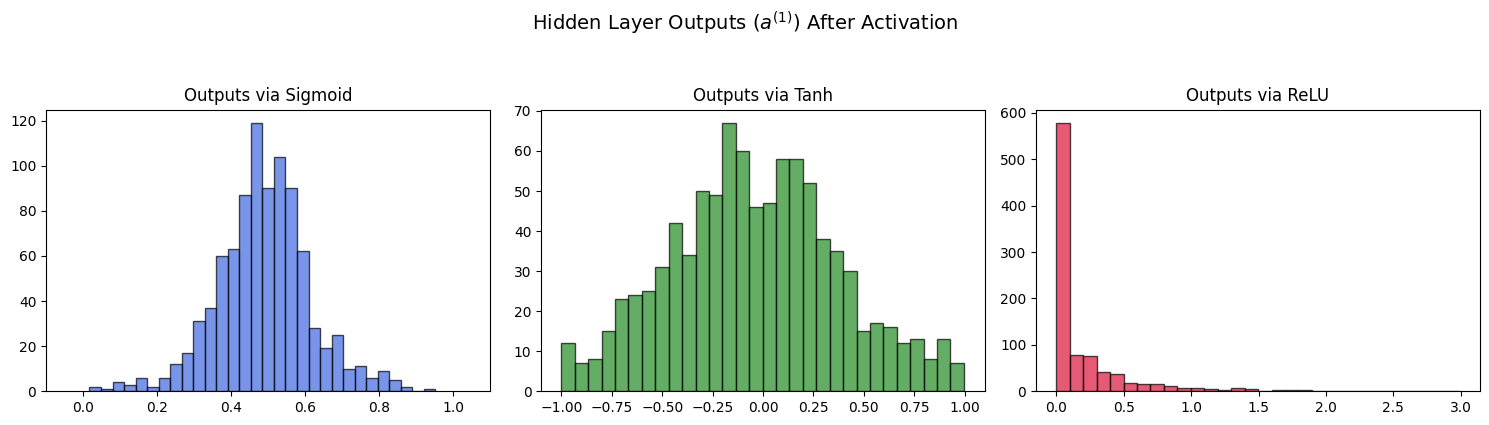

In [21]:
# 5. Plotting: Outputs (a)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Hidden Layer Outputs ($a^{(1)}$) After Activation", fontsize=14, y=1.05)

axes[0].hist(a1_sig.numpy().flatten(), bins=30, color='royalblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Outputs via Sigmoid")
axes[0].set_xlim(-0.1, 1.1) # Sigmoid forces everything between 0 and 1

axes[1].hist(a1_tanh.numpy().flatten(), bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1].set_title("Outputs via Tanh")
axes[1].set_xlim(-1.1, 1.1) # Tanh forces everything between -1 and 1

axes[2].hist(a1_relu.numpy().flatten(), bins=30, color='crimson', edgecolor='black', alpha=0.7)
axes[2].set_title("Outputs via ReLU")
# ReLU bounds (0 to +inf), with a massive spike at exactly 0.0

plt.tight_layout()
plt.show()

### Activation Function Analysis 

*   **Saturated Regions (Sigmoid and Tanh):** In the provided histograms, only a small fraction of values fall into the extreme saturated regions. For **Sigmoid**, the vast majority of outputs are concentrated between 0.3 and 0.7, with very few reaching 0 or 1. For **Tanh**, while there is a wider spread, the bulk of activations remain in the active range (between -0.75 and 0.75), with only small bars visible at the ±1 boundaries.
*   **ReLU Inactivity:** For the **ReLU** activation, a very large fraction of the units are inactive. The histogram shows a massive spike at exactly 0, accounting for nearly 600 out of roughly 900 total values (approx. **60-65%** of the units).
*   **Why ReLU is the Better Default:** 
    *   **Sparsity:** As seen,  ReLU naturally creates "sparse" representations by zeroing out a large portion of the neurons, which can lead to more efficient models.
    *   **Avoiding Gradient Vanishing:** Unlike Sigmoid and Tanh, which "squash" data and have very flat gradients at their edges (saturation), the ReLU function remains linear for all positive values. This prevents the gradients from becoming too small during backpropagation, allowing the network to learn much faster and deeper.